<a href="https://colab.research.google.com/github/hitrohitro/Vision-Transformer/blob/main/ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
!pip install -q transformers torch Pillow requests duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 58.6 MB/s eta 0:00:00


In [2]:
from transformers import pipeline
from PIL import Image
import requests

print("Downloading and loading the ViT model from Hugging Face...")
classifier = pipeline("image-classification", model="google/vit-base-patch16-224")
print("Model loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


Model loaded successfully!


What object or animal should the AI classify?: guitar

Searching Wikipedia for a real image of 'guitar'...
Image found! Downloading...


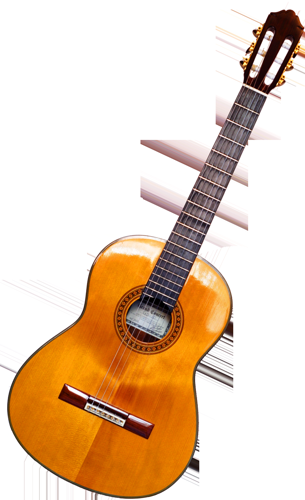

In [75]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning) # Mutes the ugly red Colab warnings

import requests
import io
from PIL import Image
from IPython.display import display

user_query = input("What object or animal should the AI classify?: ").strip()
print(f"\nSearching Wikipedia for a real image of '{user_query}'...")

try:
    # 1. Ask Wikipedia for the main summary of the topic
    wiki_url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{user_query}"
    headers = {"User-Agent": "ViTPresentationDemo/1.0 (Student Project)"}

    response = requests.get(wiki_url, headers=headers)

    if response.status_code == 404:
         print(f"Oops! Wikipedia couldn't find an exact match for '{user_query}'. Try a simpler noun.")
    else:
        response.raise_for_status()
        data = response.json()

        # 2. Extract the main image URL for that Wikipedia page
        if 'originalimage' in data:
            image_url = data['originalimage']['source']
            print("Image found! Downloading...")

            # 3. Download and display the image safely
            img_response = requests.get(image_url, headers=headers)
            img_response.raise_for_status()

            image = Image.open(io.BytesIO(img_response.content)).convert("RGB")
            image.thumbnail((500, 500))
            display(image)
        else:
            print(f"Oops! The Wikipedia page for '{user_query}' doesn't have a main image. Let's try another word.")

except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [76]:
results = classifier(image)

print("\n--- ViT Classification Results ---")
for result in results:
    label = result['label'].capitalize()
    confidence = result['score'] * 100
    print(f"Label: {label} | Confidence: {confidence:.2f}%")


--- ViT Classification Results ---
Label: Acoustic guitar | Confidence: 79.23%
Label: Electric guitar | Confidence: 16.67%
Label: Pick, plectrum, plectron | Confidence: 0.84%
Label: Banjo | Confidence: 0.51%
Label: Violin, fiddle | Confidence: 0.46%
